In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

device = torch.device("cuda:4") if torch.cuda.is_available() else torch.device("cpu")
print(f"Working with {device}")

Working with cuda:4


In [8]:
from torchvision import datasets
from torch.utils.data import DataLoader


class FastMNIST(datasets.MNIST):
    def __init__(self, *args, **kwargs):
        num_data = kwargs.pop("num_data", None)
        super().__init__(*args, **kwargs)

        self.data = self.data.float().div(255).reshape(-1, 784)
        if num_data is not None:
            self.data, self.targets = self.data[:num_data], self.targets[:num_data]
        self.data, self.targets = self.data.to(device), self.targets.to(device)

    def __getitem__(self, index):
        return self.data[index], self.targets[index]


class FastFashionMNIST(datasets.FashionMNIST):
    def __init__(self, *args, **kwargs):
        num_data = kwargs.pop("num_data", None)
        super().__init__(*args, **kwargs)

        self.data = self.data.float().div(255).reshape(-1, 784)
        if num_data is not None:
            self.data, self.targets = self.data[:num_data], self.targets[:num_data]
        self.data, self.targets = self.data.to(device), self.targets.to(device)

    def __getitem__(self, index):
        return self.data[index], self.targets[index]


num_train = 5000
train_batch_size = 100
test_batch_size = 1000

training_data = FastMNIST(root="./data", train=True, download=True, num_data=num_train)
test_data = FastMNIST(root="./data", train=False, download=True)
train_dataloader = DataLoader(
    training_data, batch_size=train_batch_size, shuffle=True, num_workers=0
)
test_dataloader = DataLoader(test_data, batch_size=test_batch_size, num_workers=0)

ood_data = FastFashionMNIST(root="./data", download=True, train=False)
ood_dataloader = DataLoader(ood_data, batch_size=test_batch_size, num_workers=0)


In [9]:
import torch.optim as optim
from evaluation import accuracy
import mfgvi
import importlib
importlib.reload(mfgvi)


num_inputs = 784
num_outputs = 10
num_hiddens = 128
num_layers = 2

def run_mfgvi(lr=5.0e-2, prior_scale=100.0, temperature=1.0):
    model = mfgvi.MFGMLP(num_inputs, num_hiddens, num_outputs, num_layers).to(device)
    opt = optim.SGD(model.parameters(), lr, momentum=0.9)   
    
    num_epochs = 100
    train_num_batches = len(train_dataloader)
    test_num_batches = len(test_dataloader)
    total_num_steps = num_epochs * train_num_batches
    scheduler = optim.lr_scheduler.CosineAnnealingLR(opt, total_num_steps)

    for epoch in range(1, num_epochs + 1):

        model.train()
        train_acc = 0.0
        train_nll = 0.0
        for x, y in train_dataloader:
            opt.zero_grad()
            pred_logits = model(x)
            nll = F.cross_entropy(pred_logits, y)
            kld = model.KLD(prior_scale) / num_train
       
            loss = nll + temperature * kld
            loss.backward()
            opt.step()
            scheduler.step()

            train_acc += accuracy(pred_logits, y).item()
            train_nll += loss.item()

        train_acc /= train_num_batches
        train_nll /= train_num_batches

        if epoch % 20 == 0:
            model.eval()
            with torch.no_grad():
                test_acc = 0.0
                test_nll = 0.0
                for x, y in test_dataloader:
                    pred_logits = model(x)
                    test_acc += accuracy(pred_logits, y)
                    test_nll += F.cross_entropy(pred_logits, y)

            test_acc /= test_num_batches
            test_nll /= test_num_batches

            kl_reg = temperature * model.KLD(prior_scale).item() / num_train
            print(
                f"Epoch {epoch}  lr {scheduler.get_last_lr()[0]:.4f} "
                f"train: nll {train_nll:.4f} acc {train_acc:.4f} kl reg {kl_reg:.4f} "
                f"test: nll {test_nll:.4f} acc {test_acc:.4f}"
            )

    return model.state_dict()



In [10]:
temperatures = [1.0, 0.1, 0.01, 0.001]
vparams = []
for temperature in temperatures:
    print(f"Running with temperature {temperature:.4f}...")
    vparams.append(run_mfgvi(temperature=temperature))

Running with temperature 1.0000...
Epoch 20  lr 0.0452 train: nll 2.4800 acc 0.5410 kl reg 1.2530 test: nll 1.2164 acc 0.5415
Epoch 40  lr 0.0327 train: nll 2.0810 acc 0.7494 kl reg 1.2969 test: nll 0.8573 acc 0.7191
Epoch 60  lr 0.0173 train: nll 1.9929 acc 0.7670 kl reg 1.2630 test: nll 0.7823 acc 0.7509
Epoch 80  lr 0.0048 train: nll 1.9285 acc 0.7762 kl reg 1.2486 test: nll 0.7579 acc 0.7554
Epoch 100  lr 0.0000 train: nll 1.9299 acc 0.7790 kl reg 1.2459 test: nll 0.7559 acc 0.7528
Running with temperature 0.1000...
Epoch 20  lr 0.0452 train: nll 0.5050 acc 0.9386 kl reg 0.3045 test: nll 0.3374 acc 0.9034
Epoch 40  lr 0.0327 train: nll 0.4414 acc 0.9566 kl reg 0.3010 test: nll 0.3374 acc 0.9068
Epoch 60  lr 0.0173 train: nll 0.4197 acc 0.9628 kl reg 0.2968 test: nll 0.2971 acc 0.9173
Epoch 80  lr 0.0048 train: nll 0.3977 acc 0.9664 kl reg 0.2947 test: nll 0.2992 acc 0.9158
Epoch 100  lr 0.0000 train: nll 0.3964 acc 0.9686 kl reg 0.2942 test: nll 0.2922 acc 0.9160
Running with tempe

In [11]:
from evaluation import evaluate
importlib.reload(mfgvi)
model = mfgvi.MFGMLP(num_inputs, num_hiddens, num_outputs, num_layers).to(device)
model.eval()
num_samples = 30

metrics = []
for vparams_ in vparams:
    model.load_state_dict(vparams_)
    with torch.no_grad():
        pred_logits = []
        for x, y in test_dataloader:            
            pred_logits.append(model(x, num_samples=num_samples))
    
        ood_pred_logits = []
        for x, y in ood_dataloader:
            ood_pred_logits.append(model(x, num_samples=num_samples))

    pred_logits = torch.cat(pred_logits, 1)
    ood_pred_logits = torch.cat(ood_pred_logits, 1)
    metrics.append(evaluate(pred_logits, ood_pred_logits, test_data.targets))


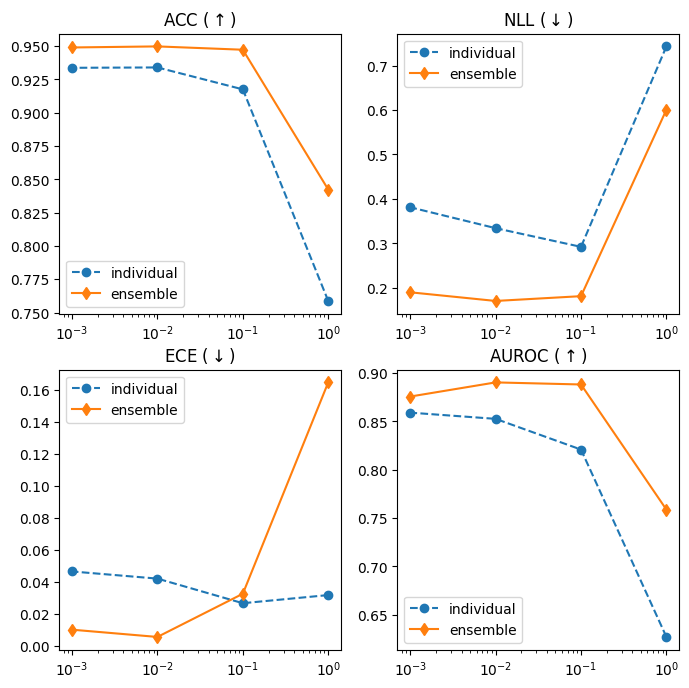

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.subplot(221)
plt.title(r"ACC ($\uparrow$)")
plt.plot(temperatures, [metrics_["indiv"]["acc"] for metrics_ in metrics], '--o', label="individual")
plt.plot(temperatures, [metrics_["ens"]["acc"] for metrics_ in metrics], '-d', label="ensemble")
plt.legend()
plt.xscale("log")

plt.subplot(222)
plt.title(r"NLL ($\downarrow$)")
plt.plot(temperatures, [metrics_["indiv"]["nll"] for metrics_ in metrics], '--o', label="individual")
plt.plot(temperatures, [metrics_["ens"]["nll"] for metrics_ in metrics], '-d', label="ensemble")
plt.legend()
plt.xscale("log")

plt.subplot(223)
plt.title(r"ECE ($\downarrow$)")
plt.plot(temperatures, [metrics_["indiv"]["ece"] for metrics_ in metrics], '--o', label="individual")
plt.plot(temperatures, [metrics_["ens"]["ece"] for metrics_ in metrics], '-d', label="ensemble")
plt.legend()
plt.xscale("log")

plt.subplot(224)
plt.title(r"AUROC ($\uparrow$)")
plt.plot(temperatures, [metrics_["indiv"]["auroc"] for metrics_ in metrics], '--o', label="individual")
plt.plot(temperatures, [metrics_["ens"]["auroc"] for metrics_ in metrics], '-d', label="ensemble")
plt.legend()
plt.xscale("log")